In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# 2. Import the dataset
df = pd.read_csv('/Users/omdevkar/Desktop/BE AIDS/02 Data Modeling & Visualization/DMV Data Set/retail_sales_dataset.csv')

In [3]:
# 3. Explore the structure and content
print(df.shape)
df.info()
df.head()


(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# 4. Identify relevant variables for aggregation
# Assume columns: 'region', 'sales_amount', 'product_category', etc.
print(df.columns)


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [5]:
# 5. Group by region and calculate total sales
region_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print(region_sales)


Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


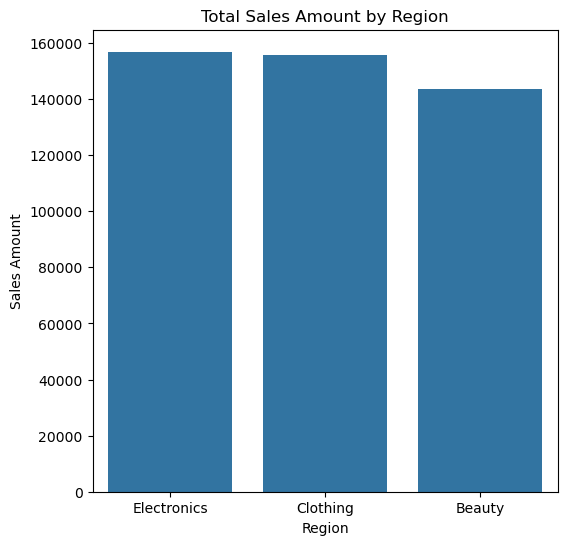

In [6]:
# 6. Visualize sales by region (bar charts)
plt.figure(figsize=(6,6))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Total Sales Amount by Region')
plt.ylabel('Sales Amount')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.show()


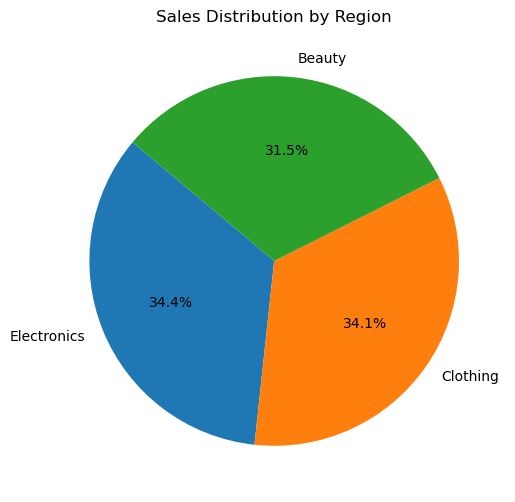

In [7]:
# Visualize sales by region (pie chart)
plt.figure(figsize=(6,6))
plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Region')
plt.show()

In [8]:
# 7. Identify top-performing regions
top_regions = region_sales.head()
print("Top-Performing Regions:")
print(top_regions)


Top-Performing Regions:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [9]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [10]:
# 8. Group by region and product category, calculate total sales
gender_category_sales = df.groupby([ 'Gender', 'Product Category'])['Total Amount'].sum().unstack()
print(gender_category_sales)


Product Category  Beauty  Clothing  Electronics
Gender                                         
Female             74830     81275        76735
Male               68685     74305        80170


# Assistant
This error occurs because the DataFrame `df` does not have a column named 'region'. The KeyError is raised when you try to group by a column that doesn't exist in your DataFrame.

Would you like me to provide the corrected code?

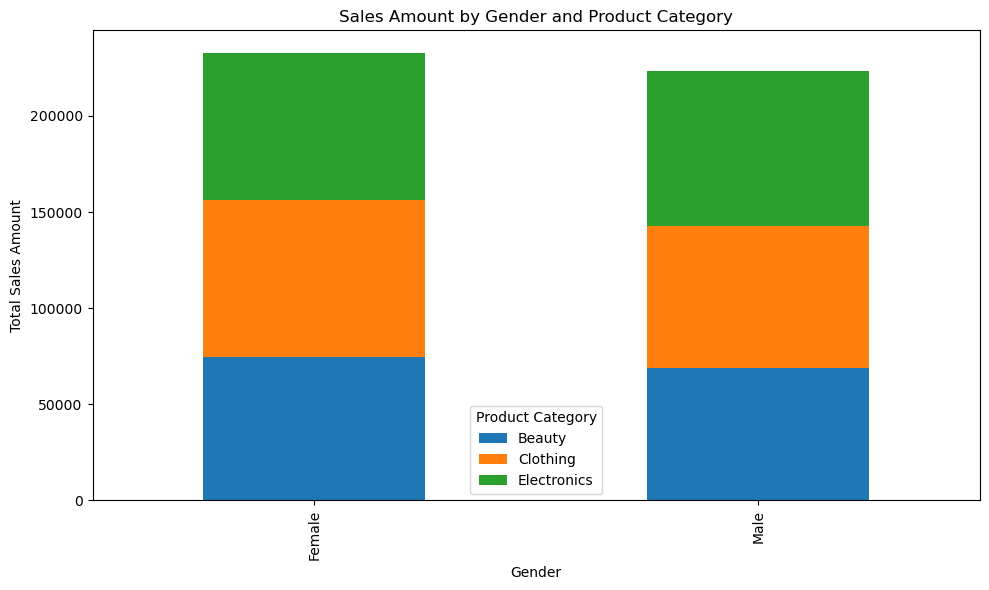

In [11]:
# 9. Stacked bar plot for Gender vs Product Category
gender_category_sales.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Sales Amount by Gender and Product Category')
plt.ylabel('Total Sales Amount')
plt.xlabel('Gender')
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()